In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Carregar os datasets CSV da pasta 'data'
customers = pd.read_csv('../data/olist_customers_dataset.csv')
geolocation = pd.read_csv('../data/olist_geolocation_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
product_translation = pd.read_csv('../data/product_category_name_translation.csv')

In [3]:
data = {
    "customers" : customers,
    "geolocation" : geolocation,
    "order_items" : order_items,
    "order_payments" : order_payments,
    "order_reviews" : order_reviews,
    "orders" : orders,
    "products" : products,
    "sellers" : sellers,
    "product_translation" : product_translation
}

In [4]:
for c, v in data.items():
    print(c, v.shape)

customers (99441, 5)
geolocation (1000163, 5)
order_items (112650, 7)
order_payments (103886, 5)
order_reviews (99224, 7)
orders (99441, 8)
products (32951, 9)
sellers (3095, 4)
product_translation (71, 2)


In [5]:
for c, v in data.items():
    print(c, v.isnull().sum().sum())

customers 0
geolocation 0
order_items 0
order_payments 0
order_reviews 145903
orders 4908
products 2448
sellers 0
product_translation 0


In [6]:
# Não será preciso retirar as duplicatas da geolocation, visto que o mesmo CEP pode abranger
# diferentes lat/lng. É bem comum, pois o CEP representa uma região, não um ponto exato.
for c, v in data.items():
    print(c, v.duplicated().sum().sum())

customers 0
geolocation 261831
order_items 0
order_payments 0
order_reviews 0
orders 0
products 0
sellers 0
product_translation 0


In [7]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [8]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [9]:
#Não será preciso realizar a tratativa desses dados, ou seja, não precisa retirar os valores nulos.
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [10]:
order_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [11]:
order_reviews["review_score"].value_counts().sort_values(ascending=False)

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

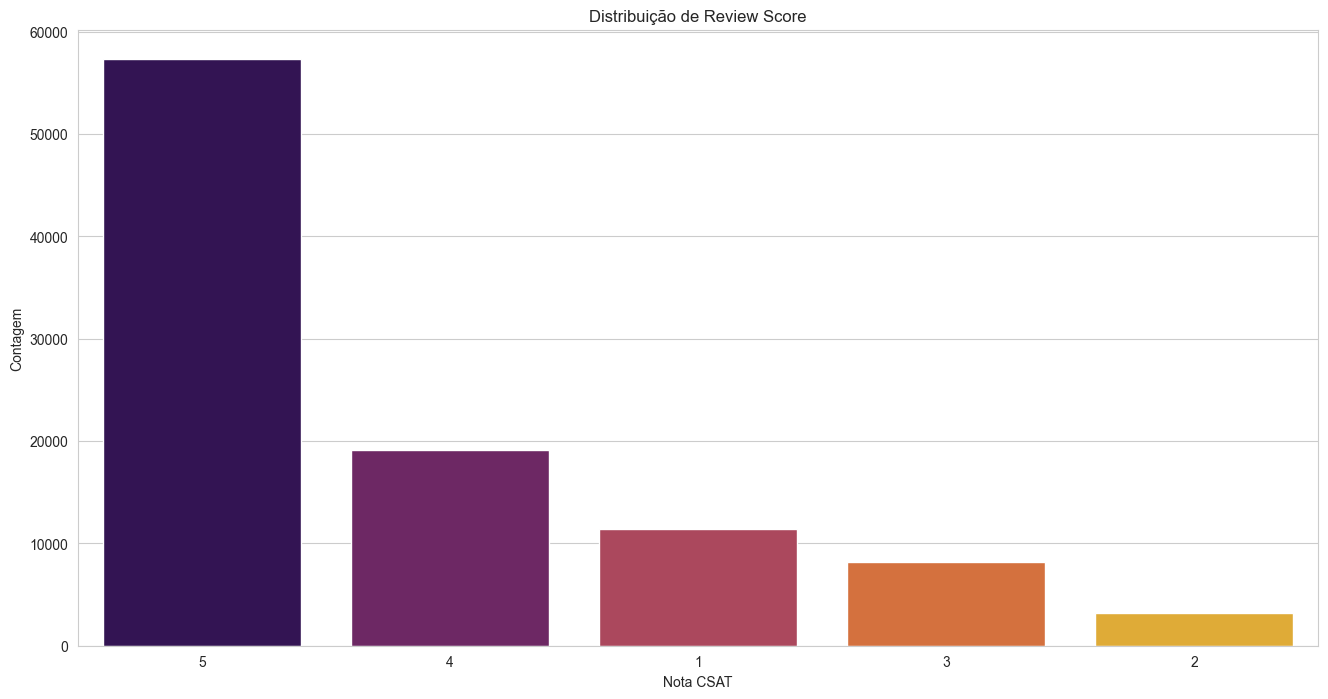

In [12]:
plt.figure(figsize=(16, 8))
sns.countplot(data=order_reviews, x="review_score", order=order_reviews["review_score"].value_counts().index, palette='inferno')
plt.title("Distribuição de Review Score")
plt.xlabel("Nota CSAT")
plt.ylabel("Contagem")
plt.show()

In [13]:
def csat(nota):
    if nota == 1:
        return "Extremamente insatisfeito"
    elif nota == 2:
        return "Insatisfeito"
    elif nota == 3:
        return "Indiferente"
    elif nota == 4:
        return "Satisfeito"
    else:
        return "Extremanete satisfeito"

In [14]:
order_reviews['CSAT'] = order_reviews['review_score'].apply(csat)

In [15]:
order_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,CSAT
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,Satisfeito
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,Extremanete satisfeito
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,Extremanete satisfeito
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,Extremanete satisfeito
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,Extremanete satisfeito
...,...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30,Extremanete satisfeito
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42,Extremanete satisfeito
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,Extremanete satisfeito
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13,Satisfeito


In [16]:
def classify(nota):
    if nota <= 2:
        return "red"
    elif nota == 3:
        return "yellow"
    else: 
        return "green"

In [17]:
order_reviews['light'] = order_reviews['review_score'].apply(classify)

In [18]:
order_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,CSAT,light
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,Satisfeito,green
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,Extremanete satisfeito,green
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,Extremanete satisfeito,green
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,Extremanete satisfeito,green
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,Extremanete satisfeito,green
...,...,...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30,Extremanete satisfeito,green
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42,Extremanete satisfeito,green
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,Extremanete satisfeito,green
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13,Satisfeito,green


In [19]:
textmininglightclean = order_reviews.dropna(subset="review_comment_message")

In [20]:
textmininglightclean

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,CSAT,light
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,Extremanete satisfeito,green
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,Extremanete satisfeito,green
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47,Satisfeito,green
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22,Satisfeito,green
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01,Extremanete satisfeito,green
...,...,...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51,Satisfeito,green
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23,Extremanete satisfeito,green
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06,Indiferente,yellow
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,Extremanete satisfeito,green


In [21]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('portuguese'))
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vitor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vitor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
# Função de pré-processamento: tokenizar, lowercase, remover stopwords e não-alfabéticos
def preprocess_text(text):
    tokens = nltk.word_tokenize(text.lower())
    filtered_tokens = []
    for word in tokens:
        if word.isalpha() and word not in stop_words:
            filtered_tokens.append(word)
    return filtered_tokens

In [39]:
# Analisar text mining para cada uma das três classes
classes = ['red', 'yellow', 'green']

for light_class in classes:
    print(f"\n{'='*60}")
    print(f"Análise para classe: {light_class.upper()}")
    print(f"{'='*60}\n")
    
    # Filtrar dados pela classe
    df_filtered = textmininglightclean[textmininglightclean['light'] == light_class]
    print(f"Total de comentários: {len(df_filtered)}\n")
    
    # Aplicar tokenização e limpeza
    df_filtered['tokens_message'] = df_filtered['review_comment_message'].apply(preprocess_text)
    
    # Agregar todos os tokens
    all_tokens = []
    for sublist in df_filtered['tokens_message']:
        for token in sublist:
            all_tokens.append(token)
    
    # Calcular frequência das palavras
    freq_dist = nltk.FreqDist(all_tokens)

    # Exibir top 50 palavras mais frequentes
    print(f"Top 15 palavras mais frequentes ({light_class}):")
    print(freq_dist.most_common(15))
    print()


Análise para classe: RED

Total de comentários: 10890

Top 15 palavras mais frequentes (red):
[('produto', 6171), ('recebi', 3265), ('comprei', 1873), ('veio', 1549), ('entrega', 1406), ('ainda', 1397), ('entregue', 1323), ('chegou', 1174), ('nao', 939), ('prazo', 908), ('compra', 902), ('pedido', 788), ('loja', 771), ('dia', 761), ('agora', 687)]


Análise para classe: YELLOW

Total de comentários: 3557

Top 15 palavras mais frequentes (yellow):
[('produto', 1588), ('recebi', 541), ('veio', 538), ('entrega', 482), ('prazo', 479), ('bom', 386), ('chegou', 358), ('comprei', 294), ('entregue', 285), ('ainda', 284), ('porém', 259), ('bem', 208), ('nao', 181), ('compra', 179), ('qualidade', 174)]


Análise para classe: GREEN

Total de comentários: 26530

Top 15 palavras mais frequentes (green):
[('produto', 10585), ('prazo', 7023), ('antes', 5275), ('entrega', 4598), ('chegou', 4003), ('bom', 3995), ('recomendo', 3807), ('bem', 2688), ('entregue', 2161), ('qualidade', 2151), ('tudo', 2084


Distribuição de Categorias - RED
categoria
entrega       7974
produto       1474
outros         929
compra         286
satisfacao     227
Name: count, dtype: int64


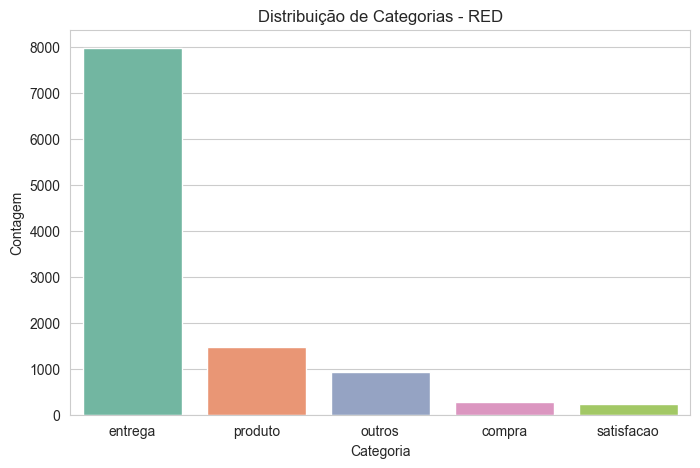


Distribuição de Categorias - YELLOW
categoria
entrega       2031
produto        726
outros         542
satisfacao     161
compra          97
Name: count, dtype: int64


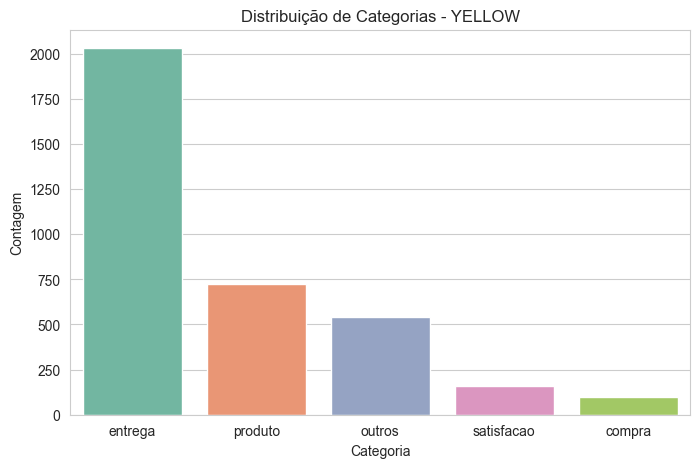


Distribuição de Categorias - GREEN
categoria
entrega       13403
produto        6305
outros         3904
satisfacao     2094
compra          824
Name: count, dtype: int64


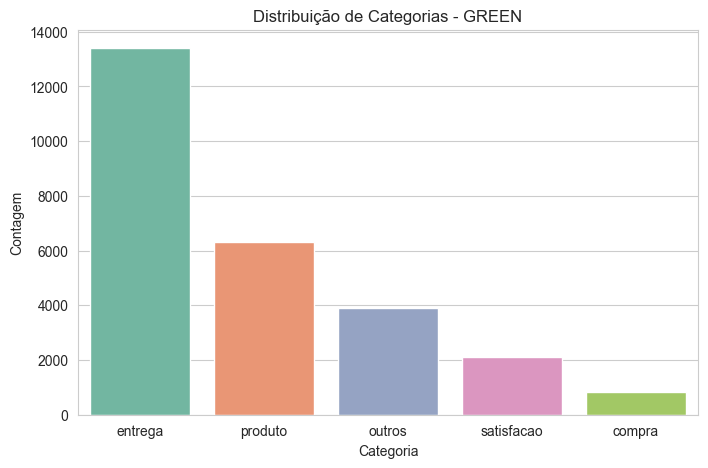

In [40]:
# Dicionário de categorias com listas de palavras-chave (baseado em análise de frequência)
categories = {
    'entrega': ["entrega", "prazo", "chegou", "recebi", "comprei", "veio", "entregue", "atraso", "demora", "transportado"],
    'produto': ["produto", "qualidade", "bom", "excelente", "ótimo", "quebrado", "defeito", "danificado"],
    'satisfacao': ["recomendo", "super", "tudo", "bem", "porém", "nao"],
    'compra': ["compra", "pedido", "loja", "preço"]
}

# Função para categorizar
def categorize_comment(text):
    if pd.isna(text):
        return 'outros'
    text_lower = text.lower()
    for cat, words in categories.items():
        if any(word in text_lower for word in words):
            return cat
    return 'outros'

# Aplicar categorização para as três classes
for light_class in classes:
    df_filtered = textmininglightclean[textmininglightclean['light'] == light_class]
    df_filtered['categoria'] = df_filtered['review_comment_message'].apply(categorize_comment)
    
    print(f"\n{'='*60}")
    print(f"Distribuição de Categorias - {light_class.upper()}")
    print(f"{'='*60}")
    print(df_filtered['categoria'].value_counts())
    
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_filtered, x='categoria', palette='Set2', order=df_filtered['categoria'].value_counts().index)
    plt.title(f"Distribuição de Categorias - {light_class.upper()}")
    plt.xlabel("Categoria")
    plt.ylabel("Contagem")
    plt.show()